<a href="https://colab.research.google.com/github/wati-i/demo/blob/main/Indian_food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.offline import init_notebook_mode
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud , ImageColorGenerator
Data = pd.read_csv("ext-indian_food.csv")

In [6]:
Data.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [8]:
Data.columns

Index(['name', 'ingredients', 'diet', 'prep_time', 'cook_time',
       'flavor_profile', 'course', 'state', 'region'],
      dtype='object')

In [10]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [12]:
Data.isnull().any()

,0
name,False
ingredients,False
diet,False
prep_time,False
cook_time,False
flavor_profile,False
course,False
state,False
region,True


In [14]:
Data.isnull().sum()

,0
name,0
ingredients,0
diet,0
prep_time,0
cook_time,0
flavor_profile,0
course,0
state,0
region,1


In [16]:
Data=Data.replace(-1,np.nan)
Data=Data.replace('-1',np.nan)
Data.head()
Data.isnull().sum()
Data.shape

(255, 9)

In [18]:
Pie_data = Data.diet.value_counts().reset_index()
Pie_data.columns = ['diet','count']
Fig = px.pie(Pie_data, values='count', names='diet', title='Proportion of Vegetarian and Non-Vegetarian dishes',
color_discrete_sequence=['green', 'red'])
Fig.show()

In [20]:
Sweet_data = Data[Data['flavor_profile']=='sweet']
Final_sweet_data = Sweet_data[Sweet_data['course']!='dessert']
display(Final_sweet_data)
Flav_data = Data.flavor_profile.value_counts().reset_index()
Flav_data.columns = ['flavor_profile', 'count']
Fig = px.bar(Flav_data,x='flavor_profile',y='count',title='Variety of item according to the flavour',
color_discrete_sequence=['green'])
Fig.show()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
46,Obbattu holige,"Maida flour, turmeric, coconut, chickpeas, jag...",vegetarian,180.0,60.0,sweet,main course,Karnataka,South
85,Dal makhani,"Red kidney beans, urad dal, cream, garam masal...",vegetarian,10.0,60.0,sweet,main course,Punjab,North
243,Mishti Chholar Dal,"Chana dal, fresh coconut, ginger, cinnamon, ra...",vegetarian,10.0,30.0,sweet,main course,West Bengal,East


In [22]:
Cooking_time = Data[['cook_time','name']]
Cooking_time.head()
Cooking_time = Cooking_time.sort_values(['cook_time'],ascending=True)
Ten_cook_quickly = Cooking_time.head(10)
#cook_data = Ten_cook_quickly.cook_time.value_counts().reset_index()
#cook_data.columns = ['cook_time', 'name']
Fig = px.bar(Ten_cook_quickly, x='cook_time', y='name', title='dishes based on cooking time',
color_discrete_sequence=['green'])
Fig.show()

In [24]:
Data.columns
Cooking_time_longest = Cooking_time.sort_values(['cook_time'],ascending=False)
Ten_cook_longest = Cooking_time_longest.head(10)

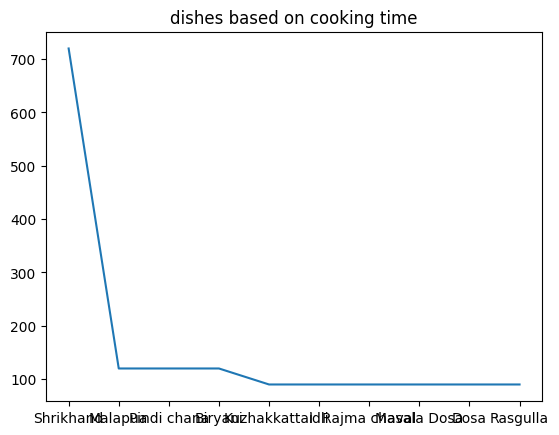

In [26]:
import matplotlib.pyplot as plt
Y=Ten_cook_longest['cook_time']
X=Ten_cook_longest['name']
plt.plot(X,Y)
plt.title('dishes based on cooking time')
plt.show()